# Example Usage of `astrotrack`

This notebook serves as a demonstration of the `astrotrack` Python package, which was developed as a tool for characterising potential LEO satellite radio frequency interference (RFI) in wide-field radio astronomy measurements. `astrotrack` offers modules for loading raw LEO satellite data (Two-Line Elements, known as TLEs) from publicly available catalogues compiled by [Space-Track](https://www.space-track.org), propagating their corresponding satellite trajectories across a user-defined duration subject to TLE validity constraints, identifying satellite flyover metrics at a user-defined instrument site, and comparing these metrics with a temporally-aligned instrument observation to identify possible contamination.

### Loading TLE Data:

There are several important user-defined parameters that must be selected at this stage, in order to isolate the target flyovers that are of interest and of concern regarding contamination. Comprehensive details on function parameters and the required inputs can be found in the following [documentation](../../docs/examples/examples.md), where a non-exhaustive explanation of the more critical parameters is provided below:
* `satcon`: As TLE catalogues contain publicly available satellite data across all LEO satellite constellations, a satellite constellation must be provided. For this demonstration, Eutelsat OneWeb will be selected.
* `horizon_data`: The horizon profile, provided in a CSV file, for the instrument or area simulated in this analysis.
* `target_date`: The observation date of the analysis, which will be set to 12:25 UTC 15 June 2025
* `obs_lan`, `obs_lon`: The location of which to calculate satellite trajectories, which will be set to the latitude ($-30.71131^{\circ}$) and longitude ($21.4476236^{\circ}$) of the REACH radiometer experiment in the Karoo radio reserve, South Africa (Scheutwinkel, K. H. et al. 2022).
* `R`: The radial contraint defining how close a satellite flyover must pass to be considered potentially interfering, should it generated unintended radiation (UEMR) during the flyover. This will be set to $1500$ km for this work, as a more conservative upper bound than the default $2000$ km representing the maximum detection distance of reported UEMR from interferometric arrays.

In [1]:
# Imports:
from datetime import datetime
from skyfield.api import load
import matplotlib.pyplot as plt
import numpy as np

For this demonstration, the orbit duration will be set to $1 \text{ hour} = 3600 \text{s}$, such that the times of which to plot the orbits (denoted as 'epochs') will be set to the target date plus the orbit duration.

In [2]:
# Time Array:
ts = load.timescale()
length = 3600  # in seconds
orbit_duration = np.arange(0, length + 1, 1)
epochs_of_orbit = ts.utc(2025, 6, 15, 12, 25, 8 + orbit_duration)
ref_locations = [["London", 51.5, 0.128], ["REACH", -30.7, -21.5]]

In [3]:
from astrotrack.preprocess import load_satellite_data

data = load_satellite_data(
    tle_file="../../data/TLE-catalogues/TLEs.txt",
    target_date=datetime(2025, 6, 15, 12, 25, 8),
    obs_len=length,
    traj_res=60,
    obs_lat=-30.71131,
    obs_lon=21.4476236,
    R=1500,
    horizon_data="../../data/horizon-profiles/REACH-Horizon.csv",
    satcon="OneWeb"
)

Processing satellites: 100%|██████████| 654/654 [00:07<00:00, 81.83satellite/s] 


### Exploring Satellite Metrics:

Several metrics and satellite properties will now be observed and investigated. This ranges from simply visualising satellite flyover trajectories projected on a 3D Earth model, to plotting the time-evolving displacement of each flyover relative to a user-defined instrument site. These properties allow for a more comprehensive assessment of each satellite flyover and its potential impact to the instrument site. Furthermore, it allows a user to compile a rough list of the satellite flyovers of interest. For example, satellites that achieve the closest distances of approach when passing over the instrument site.

In [4]:
n_flyovers = len(data)
norads = []
for flyover in data:
    tle_2 = flyover['TLE'][1].split(" ")  # get NORAD from TLE line 2
    norads.append(tle_2[1])  # append NORADs

print(f"Number of OneWeb Flyovers at REACH Site: {len(data)}")
print(f"List of NORADS: {', '.join(norads)}.")

Number of OneWeb Flyovers at REACH Site: 31
List of NORADS: 49288, 49291, 49295, 49297, 49302, 49306, 49314, 51645, 54113, 54115, 54117, 54118, 54121, 54122, 54123, 54124, 54125, 54126, 54135, 54138, 54144, 54145, 55803, 55805, 55806, 55810, 55830, 55832, 55834, 55835, 56725.


**Visualising Flyover Trajectories**

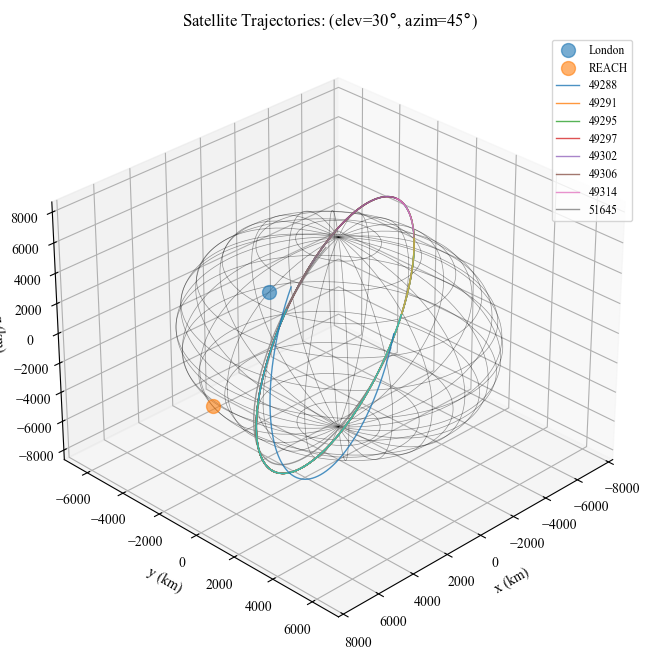

In [5]:
from astrotrack.satcon_properties import plot_satellite_trajectory

plot_satellite_trajectory(
    data,
    elev=30,
    azim=45,
    time=epochs_of_orbit,
    ref_points=ref_locations,
    show_legend=True,
    figsize=(8, 8),
    font_family="Times New Roman"
)

By plotting the satellite trajectories on the Earth model, it becomes qualitatively clear that the satellite flyovers passing within at least 1500km of the REACH site appear to share the same orbital plane. The external-Earth observer perspective of this plot can be easily modified using the `elev` and `azim` parameters, to rotate the rendered Earth model and visualise the plotted trajectories at different angles.

**Flyover's NORAD Histogram**

One can also investigate the number of generations classified as flyovers. For example, the transition between Gen.1 and Gen.2 Starlink satellites is indicated by NORAD 57457 (corresponding to STARLINK-30165). Given that the second generation of OneWeb satellites are set to launch in October 2026, the histogram can be plotted for now with no `cutoff_norad` signifying the generation transition.

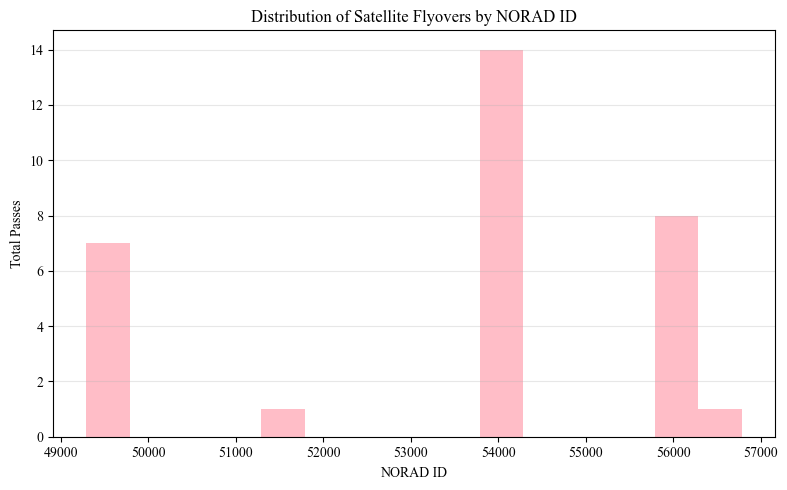

In [7]:
from astrotrack.satcon_properties import plot_flyover_histogram_by_norad

plot_flyover_histogram_by_norad(
    data,
    cutoff_norad = None,
    gap_hours=1.0,
    bin_width=500,
    color="lightpink",
    font_family="Times New Roman",
    figsize=(8, 5)
)

**Flyover Elevations over Time**

For wide-beam radiometers, like REACH, unintended satellite radiation entering the instrument's field of view at large angular distances from zenith couple weakly to the antenna, in contrast to those transiting close to zenith where the gain is maximised. As a result, satellite flyovers achieving high-elevation angles approaching $\phi = 90^{\circ}$ are of particular interest, as IEMR and UEMR in this region could couple more strongly to an instrument's beam pattern. 

C:\Users\lette\OneDrive\Desktop\Publications\RASTI AstroTrack Paper\astrotrack\astrotrack\satcon_properties.py:282: UserWarning: no explicit representation of timezones available for np.datetime64
  epochs_np = np.array([np.datetime64(e) for e in epochs])


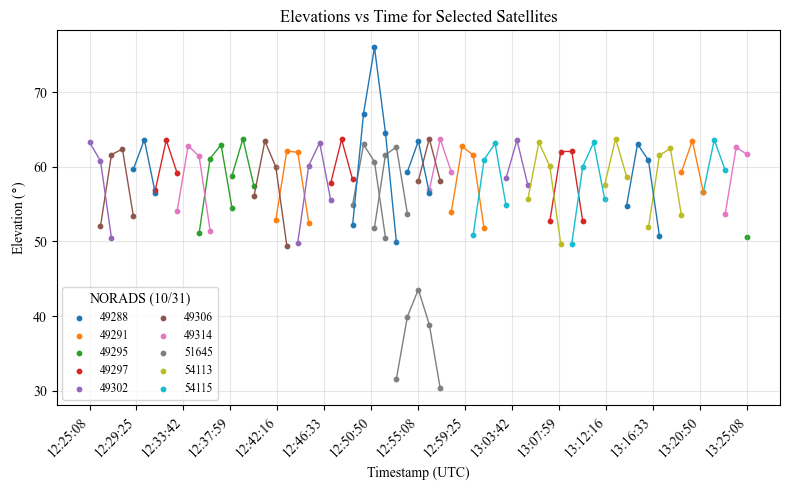

In [11]:
from astrotrack.satcon_properties import plot_satellite_metric

plot_satellite_metric(
    data,
    variable="Elevations",
    threshold=None,
    invert=False,
    font_family="Times New Roman",
    figsize=(8, 5)
)

It appears that NORAD 49288 achieves the highest $\phi$ value exceeding $70^{\circ}$, compared to the rest of the satellite flyovers entering and leaving the instrument's field of view at $\phi \in [50^{\circ}, 60^{\circ}]$ and reaching $\phi \sim 65^{\circ}$ at best. This flyover is therefore of particular interest, especially if there is a contamination event at $\sim$ 12:50.

**Flyover Animations**

In [ ]:
from astrotrack.satcon_animate import animate_trajectories

animate_trajectories(
    data,
    ref_points=ref_locations,
    duration_hours=4,
    step_seconds=60,
    start_time=datetime(2025, 6, 15, 12, 25, 8),
    output_dir=".",
    filename_prefix="animated_satellites"
)

<br>
<div align="center">
  <img src="animated_satellites_e30_a300.gif" width="800">
</div>
<br>

### Doppler Analysis:

As wide-beam radiometers cannot identify radiation sources spatially, one can investigate whether satellite contamination is resolvable by the instrument and at what hypothetical frequencies it is resolvable at. Based on previous studies reporting unintended satellite radiation (Bassa et al. 2024), the bounds of hypothetical frequencies chosen for this demonstration will be $f_{\text{UEMR}} \in [110, 188]$. The `doppler_analysis` module offers tools for testing whether contamination would be resolvable by REACH, at a resolution of 12 kHz, if unintended satellite radiation emanated from OneWeb flyovers at $f_{\text{UEMR}}$.

In [14]:
from astrotrack.satcon_properties import filter_by_norads
from astrotrack.doppler_analysis import check_doppler_resolution

subset = filter_by_norads(data, exact_id=49288)
f0_array = [110e6, 137.5e6]
check_doppler_resolution(data, f0_array, resolution=12_000, experiment="REACH")

+----------------------+---------------+---------------+----------------------------+
|   Satellite NORAD ID | 110.0 MHz     | 137.5 MHz     | Freq. to Resolve (REACH)   |
+======================+===============+===============+============================+
|                49288 | 0.80 kHz | NO | 1.00 kHz | NO | 1642 MHz                   |
+----------------------+---------------+---------------+----------------------------+
|                49291 | 1.01 kHz | NO | 1.26 kHz | NO | 1307 MHz                   |
+----------------------+---------------+---------------+----------------------------+
|                49295 | 1.10 kHz | NO | 1.38 kHz | NO | 1200 MHz                   |
+----------------------+---------------+---------------+----------------------------+
|                49297 | 0.73 kHz | NO | 0.92 kHz | NO | 1797 MHz                   |
+----------------------+---------------+---------------+----------------------------+
|                49302 | 1.15 kHz | NO | 1.44 kHz | NO

As demonstrated above, radiation emitted at $f_{\text{UEMR}}$ by OneWeb would not be resolvable by the REACH radiometer. While this indicates that spectral leakages or streaks in REACH PSD observations are not caused by OneWeb, this does not imply that there is no contamination. The next step would be to utilise the `psd_analysis` module, in order to directly compare the time and properties of flyovers with contamination events within observations, in order to characterise whether certain events can be attributed or associated with satellite flyovers.

### Bibliography

Scheutwinkel, K. H., de Lera Acedo, E., & Handley, W. (2022). *Bayesian evidence-driven diagnosis of instrumental systematics for sky-averaged 21-cm cosmology experiments*. Publications of the Astronomical Society of Australia, 39.

Bassa, C. G., Di Vruno, F., Winkel, B., et al. (2024). *Bright unintended electromagnetic radiation from second-generation Starlink satellites*. Astronomy & Astrophysics, 689, L10.
